In [5]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import os
warnings.filterwarnings('ignore')

In [6]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [7]:
df = pd.read_csv('SAR_Rental.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (10000, 19)

First 5 rows:
   row#  user_id  vehicle_model_id  package_id  travel_type_id  from_area_id  \
0     1    17712                12         NaN               2        1021.0   
1     2    17037                12         NaN               2         455.0   
2     3      761                12         NaN               2         814.0   
3     4      868                12         NaN               2         297.0   
4     5    21716                28         NaN               2        1237.0   

   to_area_id  from_city_id  to_city_id       from_date        to_date  \
0      1323.0           NaN         NaN  1/1/2013 22:33            NaN   
1      1330.0           NaN         NaN  1/1/2013 12:43            NaN   
2       393.0           NaN         NaN   1/2/2013 0:28  1/3/2013 0:00   
3       212.0           NaN         NaN  1/1/2013 13:12            NaN   
4       330.0           NaN         NaN  1/1/2013 16:33            NaN   

   online_booking  mobile_site_b

In [8]:
df['from_date'] = pd.to_datetime(df['from_date'], format='%m/%d/%Y %H:%M', errors='coerce')
df['booking_created'] = pd.to_datetime(df['booking_created'], format='%m/%d/%Y %H:%M', errors='coerce')

In [9]:
df['date'] = df['booking_created'].dt.date

In [10]:
print(f"Null values in dates: {df['date'].isna().sum()}")


Null values in dates: 0


In [11]:
df = df.dropna(subset=['date'])
print(f"Dataset shape after cleaning: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")


Dataset shape after cleaning: (10000, 20)
Date range: 2013-01-01 to 2013-11-24


In [12]:
ts_data = df.groupby('date').size().reset_index(name='count')
ts_data['date'] = pd.to_datetime(ts_data['date'])
ts_data = ts_data.sort_values('date').reset_index(drop=True)

print(f"Time series shape: {ts_data.shape}")
print(f"\nDaily rental statistics:")
print(ts_data['count'].describe())
print(f"\nFirst 10 rows of time series:")
print(ts_data.head(10))

Time series shape: (328, 2)

Daily rental statistics:
count    328.000000
mean      30.487805
std       12.187118
min        7.000000
25%       23.000000
50%       28.000000
75%       36.000000
max      132.000000
Name: count, dtype: float64

First 10 rows of time series:
        date  count
0 2013-01-01     21
1 2013-01-02     27
2 2013-01-03     12
3 2013-01-04     21
4 2013-01-05     23
5 2013-01-06     20
6 2013-01-07     31
7 2013-01-08     21
8 2013-01-09     19
9 2013-01-10     20


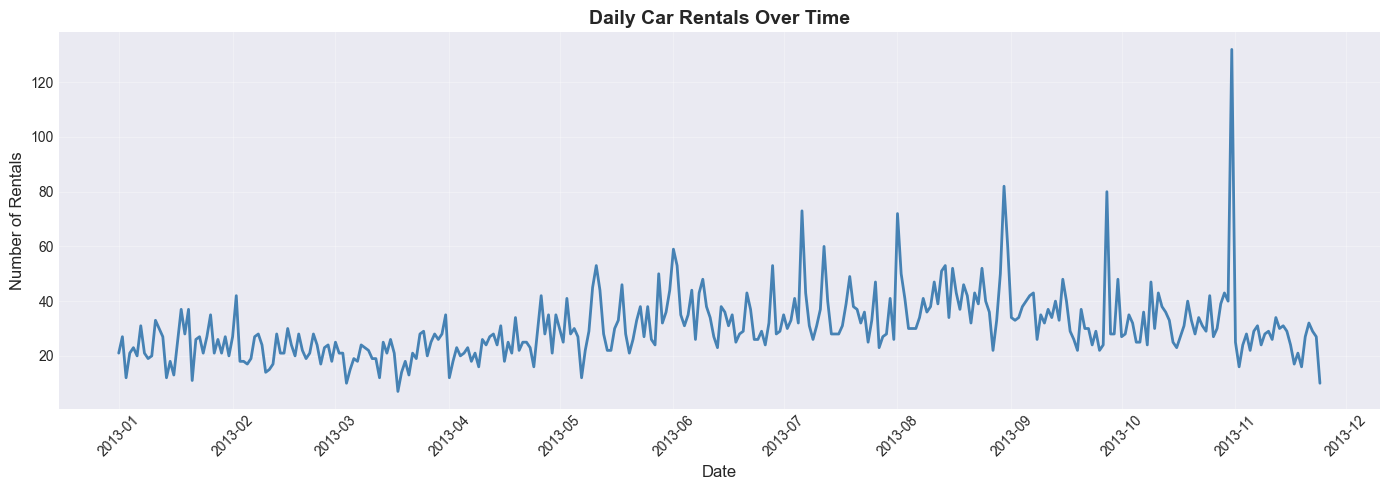


Time series information:
Total days: 328
Min rentals per day: 7
Max rentals per day: 132
Mean rentals per day: 30.49


In [13]:
plt.figure(figsize=(14, 5))
plt.plot(ts_data['date'], ts_data['count'], linewidth=2, color='steelblue')
plt.title('Daily Car Rentals Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Rentals', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nTime series information:")
print(f"Total days: {len(ts_data)}")
print(f"Min rentals per day: {ts_data['count'].min()}")
print(f"Max rentals per day: {ts_data['count'].max()}")
print(f"Mean rentals per day: {ts_data['count'].mean():.2f}")

In [14]:
prophet_df = ts_data.copy()
prophet_df.columns = ['ds', 'y']

# Split data into train and test sets (80-20 split)
train_size = int(len(prophet_df) * 0.8)
train_data = prophet_df[:train_size]
test_data = prophet_df[train_size:]

print(f"Training set size: {len(train_data)} days")
print(f"Test set size: {len(test_data)} days")
print(f"\nTrain date range: {train_data['ds'].min()} to {train_data['ds'].max()}")
print(f"Test date range: {test_data['ds'].min()} to {test_data['ds'].max()}")

Training set size: 262 days
Test set size: 66 days

Train date range: 2013-01-01 00:00:00 to 2013-09-19 00:00:00
Test date range: 2013-09-20 00:00:00 to 2013-11-24 00:00:00


In [15]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95,
    seasonality_mode='additive',  # or 'multiplicative'
    seasonality_prior_scale=10
)

print("Training Prophet model...")
with open(os.devnull, 'w') as devnull:
    model.fit(train_data)
print("✓ Model training completed!")

09:47:47 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet model...


09:47:47 - cmdstanpy - INFO - Chain [1] done processing


✓ Model training completed!


In [16]:
# 9. MAKE PREDICTIONS ON TEST SET
forecast_test = model.predict(test_data[['ds']])
forecast_test = forecast_test[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_test = forecast_test.reset_index(drop=True)

# Combine actual and predicted values
comparison = test_data.reset_index(drop=True).copy()
comparison['yhat'] = forecast_test['yhat'].values
comparison['yhat_lower'] = forecast_test['yhat_lower'].values
comparison['yhat_upper'] = forecast_test['yhat_upper'].values

print("Test Set Predictions (first 10 rows):")
print(comparison.head(10))

Test Set Predictions (first 10 rows):
          ds   y       yhat  yhat_lower  yhat_upper
0 2013-09-20  37  36.461255   21.123896   50.707775
1 2013-09-21  30  34.843580   20.670630   49.633084
2 2013-09-22  30  28.909959   14.130439   43.180643
3 2013-09-23  24  23.777375    9.960102   37.231243
4 2013-09-24  29  23.139131    9.462875   37.425701
5 2013-09-25  22  22.753563    9.263663   37.585406
6 2013-09-26  24  24.736303   10.562825   39.180329
7 2013-09-27  80  30.112439   15.390565   45.099302
8 2013-09-28  28  28.571814   14.197139   41.956996
9 2013-09-29  28  22.805629    7.742863   37.210913


In [17]:
mae = mean_absolute_error(comparison['y'], comparison['yhat'])
rmse = np.sqrt(mean_squared_error(comparison['y'], comparison['yhat']))
r2 = r2_score(comparison['y'], comparison['yhat'])
mape = np.mean(np.abs((comparison['y'] - comparison['yhat']) / comparison['y'])) * 100

print("="*50)
print("MODEL PERFORMANCE METRICS (Test Set)")
print("="*50)
print(f"Mean Absolute Error (MAE):     {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R² Score:                      {r2:.4f}")
print("="*50)


MODEL PERFORMANCE METRICS (Test Set)
Mean Absolute Error (MAE):     8.90
Root Mean Squared Error (RMSE): 16.35
Mean Absolute Percentage Error (MAPE): 26.39%
R² Score:                      -0.1062


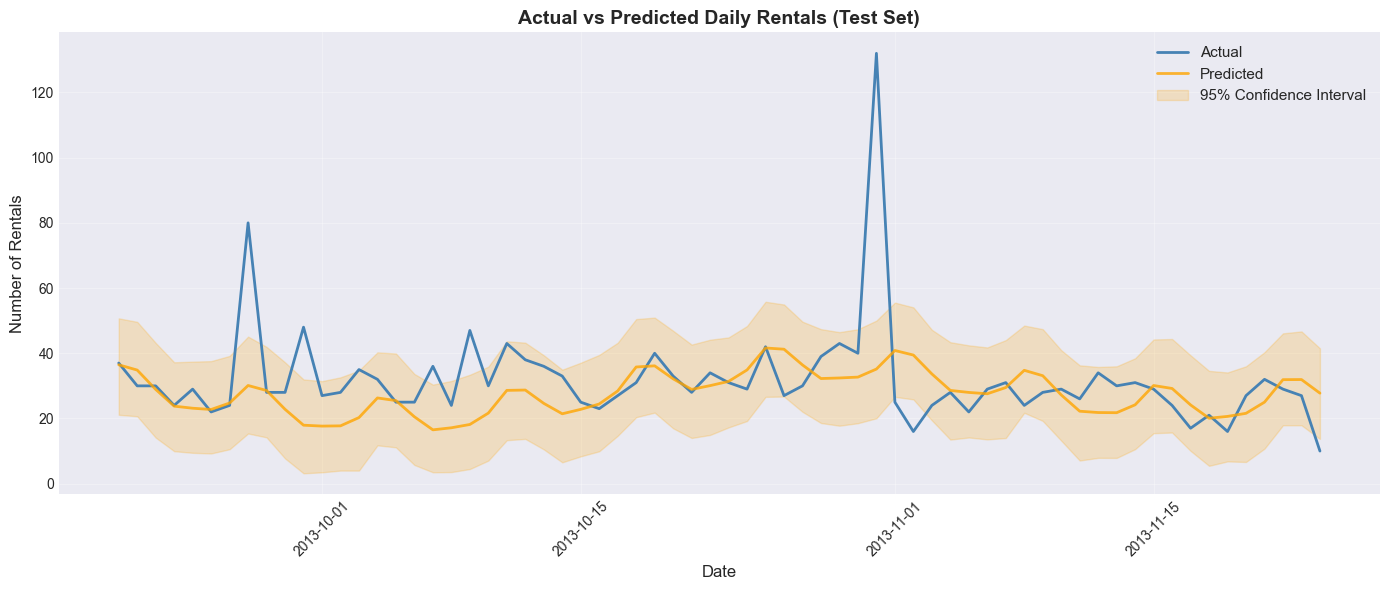

In [18]:
plt.figure(figsize=(14, 6))
plt.plot(comparison['ds'], comparison['y'], label='Actual', linewidth=2, color='steelblue')
plt.plot(comparison['ds'], comparison['yhat'], label='Predicted', linewidth=2, color='orange', alpha=0.8)
plt.fill_between(comparison['ds'], 
                 comparison['yhat_lower'], 
                 comparison['yhat_upper'], 
                 alpha=0.2, color='orange', label='95% Confidence Interval')
plt.title('Actual vs Predicted Daily Rentals (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Rentals', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95,
    seasonality_mode='additive',
    seasonality_prior_scale=10
)

print("Retraining model on full dataset...")
with open(os.devnull, 'w') as devnull:
    final_model.fit(prophet_df)
print("✓ Full model training completed!")


09:47:47 - cmdstanpy - INFO - Chain [1] start processing
09:47:47 - cmdstanpy - INFO - Chain [1] done processing


Retraining model on full dataset...
✓ Full model training completed!


In [20]:
# 13. CREATE FUTURE DATAFRAME AND FORECAST
# Forecast for the next 30 days
future = final_model.make_future_dataframe(periods=30, freq='D')
forecast = final_model.predict(future)

# Display forecast for next 30 days
future_forecast = forecast[forecast['ds'] > prophet_df['ds'].max()][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

print("Forecast for Next 30 Days:")
print(future_forecast.to_string(index=False))


Forecast for Next 30 Days:
        ds      yhat  yhat_lower  yhat_upper
2013-11-25 18.863836    0.495621   36.976837
2013-11-26 18.747300   -0.683062   37.025490
2013-11-27 20.058938    1.751731   37.809054
2013-11-28 24.832069    7.335824   42.858241
2013-11-29 29.604875   11.331672   46.968408
2013-11-30 27.659456    9.840495   46.128650
2013-12-01 23.788181    6.524390   43.504678
2013-12-02 21.844538    3.183106   41.071478
2013-12-03 21.914978    3.573548   39.784100
2013-12-04 23.306125    4.322598   41.802125
2013-12-05 28.051296    8.574790   45.927725
2013-12-06 32.691317   14.460579   51.189409
2013-12-07 30.513488   11.560345   49.552110
2013-12-08 26.317776    8.211659   44.190467
2013-12-09 23.967441    5.331074   43.111879
2013-12-10 23.560616    3.692112   41.452733
2013-12-11 24.417189    5.702504   43.717000
2013-12-12 28.584970   10.951440   49.057035
2013-12-13 32.620127   14.701700   48.855945
2013-12-14 29.825742   10.907687   47.567338
2013-12-15 25.017598    7.25

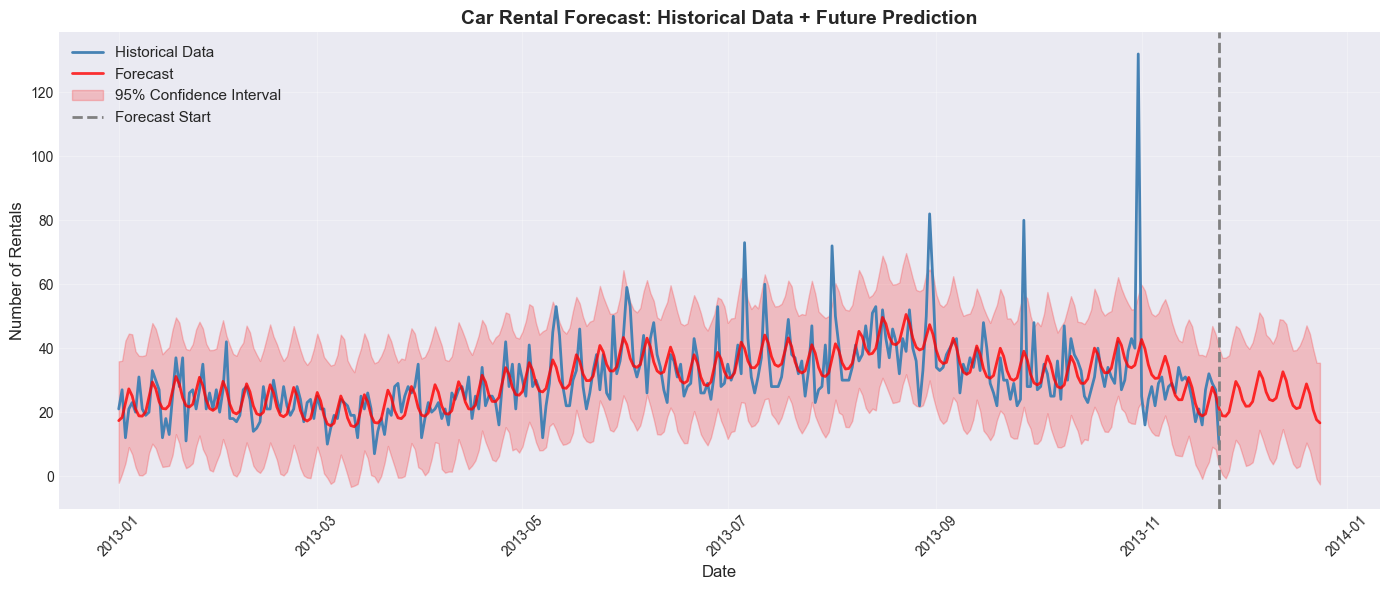

In [21]:
plt.figure(figsize=(14, 6))
plt.plot(prophet_df['ds'], prophet_df['y'], label='Historical Data', linewidth=2, color='steelblue')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', linewidth=2, color='red', alpha=0.8)
plt.fill_between(forecast['ds'], 
                 forecast['yhat_lower'], 
                 forecast['yhat_upper'], 
                 alpha=0.2, color='red', label='95% Confidence Interval')
plt.axvline(x=prophet_df['ds'].max(), color='gray', linestyle='--', linewidth=2, label='Forecast Start')
plt.title('Car Rental Forecast: Historical Data + Future Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Rentals', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


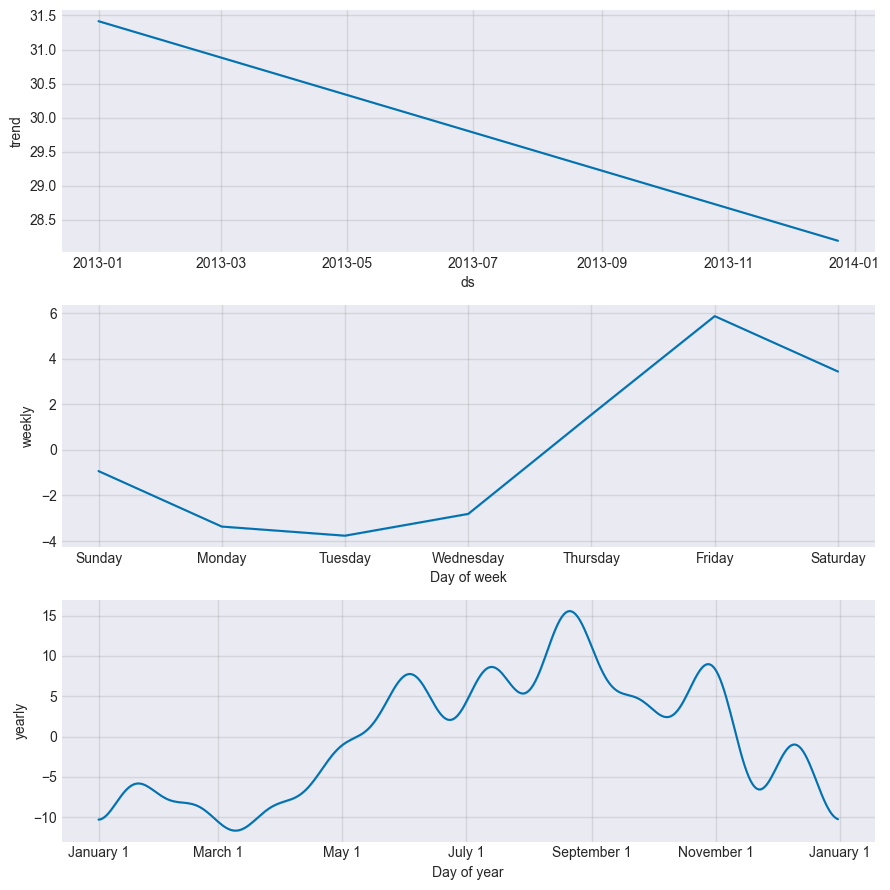


Forecasting Components:
- Trend: Overall direction of rental demand
- Yearly: Seasonal patterns within the year
- Weekly: Weekly patterns in rental demand


In [22]:
fig = final_model.plot_components(forecast, yearly_start=0)
plt.tight_layout()
plt.show()

print("\nForecasting Components:")
print("- Trend: Overall direction of rental demand")
print("- Yearly: Seasonal patterns within the year")
print("- Weekly: Weekly patterns in rental demand")


In [23]:
next_30_days = forecast[forecast['ds'] > prophet_df['ds'].max()]

print("\n" + "="*50)
print("30-DAY FORECAST SUMMARY")
print("="*50)
print(f"Average predicted daily rentals: {next_30_days['yhat'].mean():.2f}")
print(f"Min predicted daily rentals: {next_30_days['yhat'].min():.2f}")
print(f"Max predicted daily rentals: {next_30_days['yhat'].max():.2f}")
print(f"Total predicted rentals (30 days): {next_30_days['yhat'].sum():.0f}")
print("="*50)

# Compare with historical averages
print("\nComparison with Historical Data:")
print(f"Historical average daily rentals: {prophet_df['y'].mean():.2f}")
pct_change = ((next_30_days['yhat'].mean() - prophet_df['y'].mean()) / prophet_df['y'].mean() * 100)
print(f"Forecast vs Historical (% change): {pct_change:.2f}%")


30-DAY FORECAST SUMMARY
Average predicted daily rentals: 24.52
Min predicted daily rentals: 16.63
Max predicted daily rentals: 32.69
Total predicted rentals (30 days): 736

Comparison with Historical Data:
Historical average daily rentals: 30.49
Forecast vs Historical (% change): -19.58%


In [24]:
# 17. SAVE PREDICTIONS TO CSV
# Save the full forecast
forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_output.columns = ['Date', 'Forecast', 'Lower_Bound', 'Upper_Bound']
forecast_output.to_csv('car_rental_forecast.csv', index=False)

# Save test set comparison
comparison_output = comparison[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
comparison_output.columns = ['Date', 'Actual', 'Predicted', 'Lower_Bound', 'Upper_Bound']
comparison_output.to_csv('test_set_predictions.csv', index=False)

print("✓ Forecast saved to 'car_rental_forecast.csv'")
print("✓ Test predictions saved to 'test_set_predictions.csv'")

✓ Forecast saved to 'car_rental_forecast.csv'
✓ Test predictions saved to 'test_set_predictions.csv'


In [25]:
# 18. MODEL TUNING PARAMETERS (OPTIONAL)
print("\n" + "="*50)
print("PARAMETER TUNING GUIDE")
print("="*50)
print("\nseasonality_mode: 'additive' or 'multiplicative'")
print("  - Use 'additive' if seasonality is constant")
print("  - Use 'multiplicative' if seasonality grows with trend")
print("\nseasonality_prior_scale: [5, 10, 15, 20]")
print("  - Higher values = stronger seasonality")
print("\nchangepoint_prior_scale: [0.001, 0.01, 0.1]")
print("  - Higher values = more flexible trend")
print("\ninterval_width: [0.80, 0.90, 0.95]")
print("  - Width of confidence interval")


PARAMETER TUNING GUIDE

seasonality_mode: 'additive' or 'multiplicative'
  - Use 'additive' if seasonality is constant
  - Use 'multiplicative' if seasonality grows with trend

seasonality_prior_scale: [5, 10, 15, 20]
  - Higher values = stronger seasonality

changepoint_prior_scale: [0.001, 0.01, 0.1]
  - Higher values = more flexible trend

interval_width: [0.80, 0.90, 0.95]
  - Width of confidence interval
